In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Datasets/b2b_reviews_dataset.csv')

print("Total reviews:", len(df))
print("\nReviews per product:")
print(df['product_name'].value_counts())
print("\nRating distribution:")
print(df['review_rating'].value_counts().sort_index())
print("\nSample review:")
print(df['review_content'].iloc[0][:300])

Total reviews: 7000

Reviews per product:
product_name
Pipedrive                 1000
Intercom                  1000
ActiveCampaign            1000
Mixpanel                  1000
monday Work Management    1000
Notion                    1000
Asana                     1000
Name: count, dtype: int64

Rating distribution:
review_rating
0.0      40
0.5       8
1.0      31
1.5      21
2.0      19
2.5      66
3.0     105
3.5     306
4.0    1008
4.5    1633
5.0    3763
Name: count, dtype: int64

Sample review:
What do you like best about Pipedrive?
Pipedrive has sucessfully structured their CRM with humans in mind who may not be experts at using complex software. They have made it simple without compromising critical features. We use it every day for simple sales to complicated tenders and projects and Pi


In [4]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'What do you like best about[^?]+\?', '', text)
    text = re.sub(r'What do you dislike about[^?]+\?', '', text)
    text = re.sub(r'What problems is[^?]+\?', '', text)
    text = re.sub(r'Recommendations to others[^:]+:', '', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review_content'].apply(clean_text)

def label_intent(text):
    if not isinstance(text, str):
        return 'Neutral'
    text_lower = text.lower()

    if any(kw in text_lower for kw in [
        'we chose', 'we selected', 'we decided', 'we purchased',
        'we bought', 'switched to', 'migrated to', 'moved to',
        'after evaluating', 'after comparing', 'best option',
        'decided to go with', 'went with'
    ]):
        return 'High Purchase Intent'

    elif any(kw in text_lower for kw in [
        'switched from', 'moving away', 'cancelled', 'canceling',
        'looking for alternative', 'considering switching',
        'will not renew', 'stopped using', 'replaced by',
        'migrated away', 'churned', 'left for'
    ]):
        return 'Churn Intent'

    elif any(kw in text_lower for kw in [
        'evaluating', 'comparing', 'trialing', 'trial',
        'testing', 'piloting', 'considering', 'looking into',
        'assessment', 'exploring options', 'shortlisted'
    ]):
        return 'Evaluation Intent'

    elif any(kw in text_lower for kw in [
        'highly recommend', 'strongly recommend', 'would recommend',
        'tell everyone', 'best tool', 'best software', 'game changer',
        'must have', 'cant imagine without', "can't imagine without"
    ]):
        return 'Advocacy Intent'

    else:
        return 'Neutral'

df['intent_label'] = df['clean_review'].apply(label_intent)

print("Intent label distribution:")
print(df['intent_label'].value_counts())
print()
print("Sample labeled review:")
sample = df[df['intent_label'] == 'High Purchase Intent'].iloc[0]
print(f"Label: {sample['intent_label']}")
print(f"Review: {sample['clean_review'][:200]}")

Intent label distribution:
intent_label
Neutral                 6506
Advocacy Intent          230
Evaluation Intent        183
High Purchase Intent      60
Churn Intent              21
Name: count, dtype: int64

Sample labeled review:
Label: High Purchase Intent
Review: The software made it easy to import contacts and it is easy to use. I really don't have any complaints about the product, after testing 10 products, this is the one we decided to go with. I am able to


## **Intent Classification**

In [4]:
def label_intent_v2(text):
    if not isinstance(text, str):
        return 'Neutral'
    text_lower = text.lower()

    if any(kw in text_lower for kw in [
        'we chose', 'we selected', 'we decided', 'we purchased',
        'we bought', 'switched to', 'migrated to', 'moved to',
        'after evaluating', 'after comparing', 'best option',
        'decided to go with', 'went with', 'we implemented',
        'we adopted', 'we onboarded', 'we signed up', 'we upgraded',
        'chose this', 'selected this', 'picked this', 'we use it for',
        'our team chose', 'our company chose', 'we deploy'
    ]):
        return 'High Purchase Intent'

    elif any(kw in text_lower for kw in [
        'switched from', 'moving away', 'cancelled', 'canceling',
        'looking for alternative', 'considering switching',
        'will not renew', 'stopped using', 'replaced by',
        'migrated away', 'churned', 'left for', 'moving to another',
        'not worth', 'discontinue', 'unsubscribed', 'downgraded',
        'too expensive', 'overpriced', 'not renewing', 'cancellation',
        'switching to', 'looking for something else', 'disappointed'
    ]):
        return 'Churn Intent'

    elif any(kw in text_lower for kw in [
        'evaluating', 'comparing', 'trialing', 'trial',
        'testing', 'piloting', 'considering', 'looking into',
        'assessment', 'exploring options', 'shortlisted',
        'demo', 'free trial', 'proof of concept', 'poc',
        'before buying', 'before purchasing', 'alternatives',
        'compared to', 'vs ', 'versus', 'other options',
        'before we decided', 'researching'
    ]):
        return 'Evaluation Intent'

    elif any(kw in text_lower for kw in [
        'highly recommend', 'strongly recommend', 'would recommend',
        'tell everyone', 'best tool', 'best software', 'game changer',
        'must have', 'cant imagine without', "can't imagine without",
        'love this', 'absolutely love', 'excellent tool', 'perfect tool',
        'outstanding', 'fantastic tool', 'incredible tool',
        'best crm', 'best platform', 'best solution', 'top notch',
        'five stars', '5 stars', 'no brainer', 'worth every penny'
    ]):
        return 'Advocacy Intent'

    else:
        return 'Neutral'

df['intent_label'] = df['clean_review'].apply(label_intent_v2)

print("Updated intent distribution:")
print(df['intent_label'].value_counts())
print()
print("Percentages:")
print(df['intent_label'].value_counts(normalize=True).mul(100).round(1))

Updated intent distribution:
intent_label
Neutral                 6042
Evaluation Intent        423
Advocacy Intent          351
High Purchase Intent     105
Churn Intent              79
Name: count, dtype: int64

Percentages:
intent_label
Neutral                 86.3
Evaluation Intent        6.0
Advocacy Intent          5.0
High Purchase Intent     1.5
Churn Intent             1.1
Name: proportion, dtype: float64


## **Balancing Dataset**

In [5]:
# Separate neutral and labeled reviews
neutral = df[df['intent_label'] == 'Neutral'].sample(n=800, random_state=42)
labeled = df[df['intent_label'] != 'Neutral']

# Combine into balanced dataset
df_balanced = pd.concat([labeled, neutral]).reset_index(drop=True)

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced dataset size:", len(df_balanced))
print("\nLabel distribution:")
print(df_balanced['intent_label'].value_counts())
print("\nPercentages:")
print(df_balanced['intent_label'].value_counts(normalize=True).mul(100).round(1))

# Final clean dataset
df_balanced.to_csv('/content/drive/MyDrive/b2b_reviews_balanced.csv', index=False)


Balanced dataset size: 1294

Label distribution:
intent_label
Neutral                 800
Advocacy Intent         230
Evaluation Intent       183
High Purchase Intent     60
Churn Intent             21
Name: count, dtype: int64

Percentages:
intent_label
Neutral                 61.8
Advocacy Intent         17.8
Evaluation Intent       14.1
High Purchase Intent     4.6
Churn Intent             1.6
Name: proportion, dtype: float64


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/b2b_reviews_balanced.csv')
print("Dataset loaded! Shape:", df.shape)
print(df['intent_label'].value_counts())

Dataset loaded! Shape: (1758, 11)
intent_label
Neutral                 800
Evaluation Intent       423
Advocacy Intent         351
High Purchase Intent    105
Churn Intent             79
Name: count, dtype: int64


## **Fixing NaN Values**

In [6]:
df['clean_review'] = df['clean_review'].fillna('').astype(str)
print("Empty reviews:", (df['clean_review'] == '').sum())

Empty reviews: 10


## **Model 1: LR**

LOGISTIC REGRESSION RESULTS
                      precision    recall  f1-score   support

     Advocacy Intent       0.74      0.33      0.46        70
        Churn Intent       0.00      0.00      0.00        16
   Evaluation Intent       0.51      0.44      0.47        85
High Purchase Intent       0.00      0.00      0.00        21
             Neutral       0.57      0.89      0.69       160

            accuracy                           0.57       352
           macro avg       0.37      0.33      0.32       352
        weighted avg       0.53      0.57      0.52       352



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


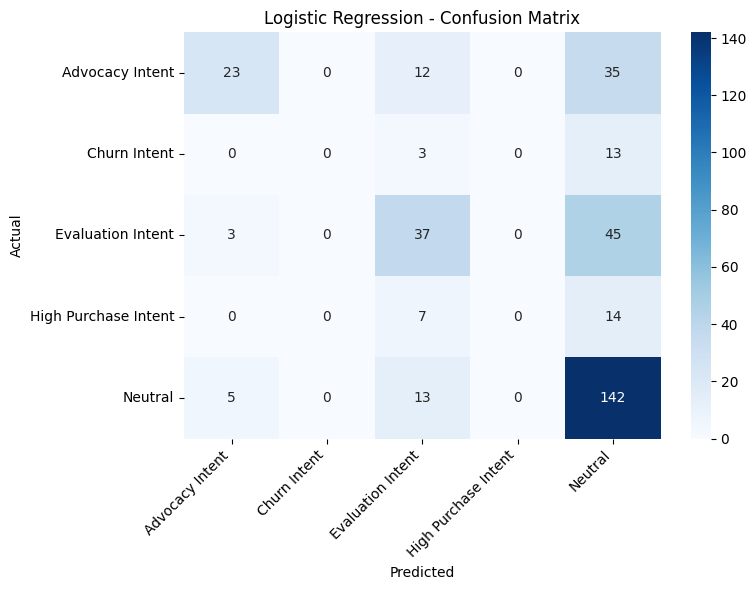

✅ Chart saved to Drive!


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data
X = df['clean_review']
y = df['intent_label']

# 2. Split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# 5. Evaluate
y_pred = lr_model.predict(X_test_tfidf)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred))

# 6. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lr_confusion_matrix.png')
plt.show()
print("✅ Chart saved to Drive!")

## **Model 2: SVM**

SVM RESULTS
                      precision    recall  f1-score   support

     Advocacy Intent       0.64      0.61      0.63        70
        Churn Intent       0.00      0.00      0.00        16
   Evaluation Intent       0.56      0.61      0.58        85
High Purchase Intent       0.83      0.24      0.37        21
             Neutral       0.65      0.75      0.69       160

            accuracy                           0.62       352
           macro avg       0.54      0.44      0.46       352
        weighted avg       0.61      0.62      0.60       352



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


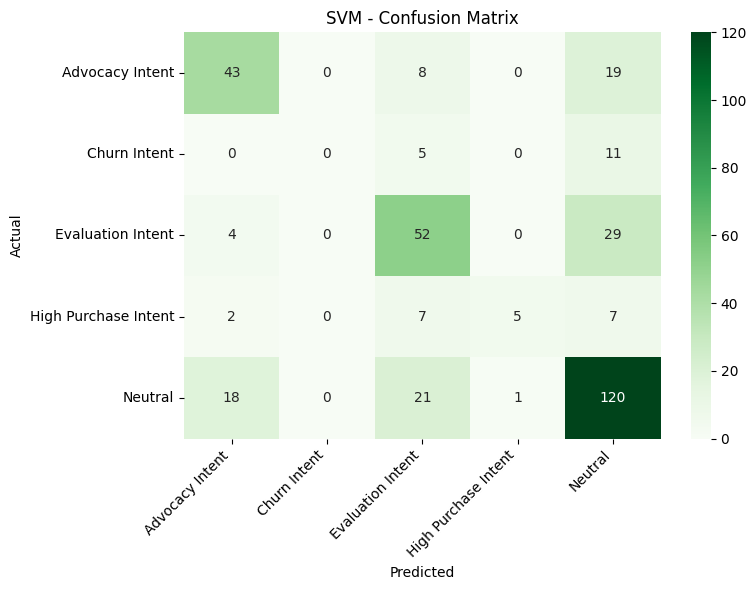

✅ SVM chart saved to Drive!


In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train SVM
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test_tfidf)
print("=" * 50)
print("SVM RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svm_confusion_matrix.png')
plt.show()
print("✅ SVM chart saved to Drive!")

## **Model 3: DistilBERT Fine-tuning**

In [7]:
!pip install transformers torch -q
print("Installed!")

Installed!


In [8]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Encode labels to numbers
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['intent_label'])
print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")

Using device: cuda
Label mapping:
  0 = Advocacy Intent
  1 = Churn Intent
  2 = Evaluation Intent
  3 = High Purchase Intent
  4 = Neutral


In [9]:
from sklearn.model_selection import train_test_split

# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_review'].tolist(),
    df['label_encoded'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256)

print("✅ Tokenization done!")
print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenization done!
Training samples: 1406
Test samples: 352


In [10]:
# Create PyTorch Dataset
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

# Load DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5
)
model.to(device)

# Training setup
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)
optimizer = AdamW(model.parameters(), lr=2e-5)

print("✅ Model loaded and ready!")
print(f"Training batches: {len(train_loader)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded and ready!
Training batches: 88


In [11]:
# TRAINING LOOP
print("🚀 Starting DistilBERT training...")

for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/3 complete ✅ | Avg Loss: {avg_loss:.4f}")

print("\ Training complete!")

<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-222/424093923.py:22: SyntaxWarning: invalid escape sequence '\ '
  print("\ Training complete!")


🚀 Starting DistilBERT training...
Epoch 1/3 complete ✅ | Avg Loss: 1.3336
Epoch 2/3 complete ✅ | Avg Loss: 1.1498
Epoch 3/3 complete ✅ | Avg Loss: 0.8426
\ Training complete!


DISTILBERT RESULTS
                      precision    recall  f1-score   support

     Advocacy Intent       0.77      0.79      0.78        70
        Churn Intent       0.00      0.00      0.00        16
   Evaluation Intent       0.65      0.66      0.65        85
High Purchase Intent       0.00      0.00      0.00        21
             Neutral       0.71      0.87      0.78       160

            accuracy                           0.71       352
           macro avg       0.43      0.46      0.44       352
        weighted avg       0.64      0.71      0.67       352



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


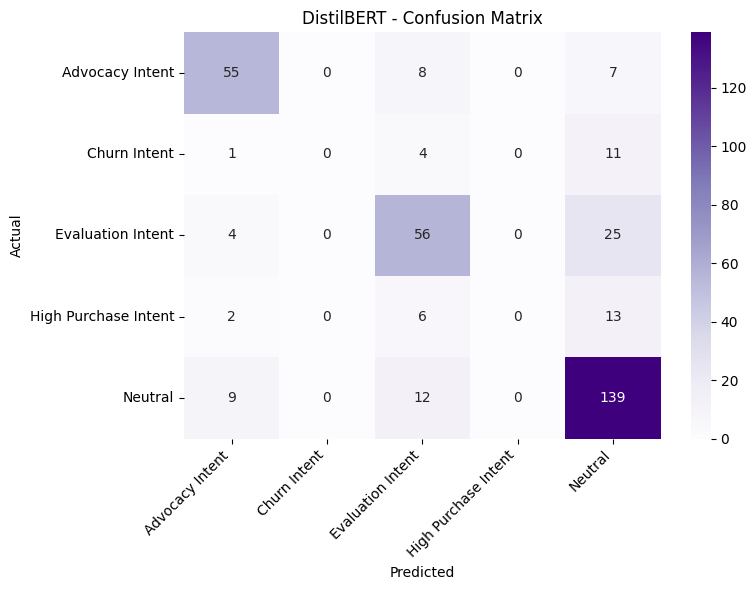

✅ Saved to Drive!


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate DistilBERT
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert back to label names
pred_labels = le.inverse_transform(all_preds)
true_labels = le.inverse_transform(all_labels)

print("=" * 50)
print("DISTILBERT RESULTS")
print("=" * 50)
print(classification_report(true_labels, pred_labels))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(true_labels, pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('DistilBERT - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/distilbert_confusion_matrix.png')
plt.show()
print("✅ Saved to Drive!")

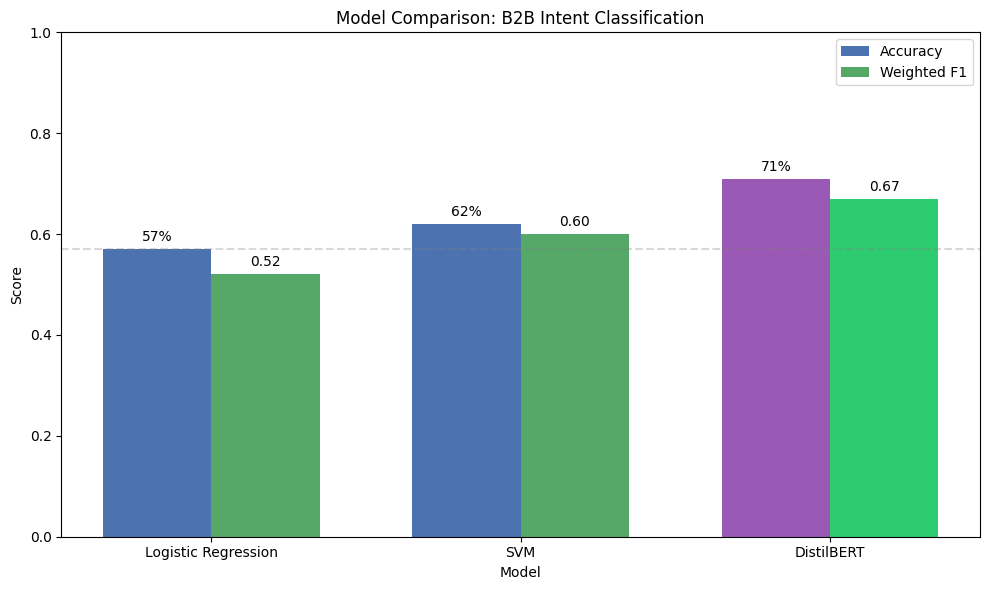

✅ Comparison chart saved to Drive!


In [13]:
# Final comparison chart
models = ['Logistic Regression', 'SVM', 'DistilBERT']
accuracy = [0.57, 0.62, 0.71]
weighted_f1 = [0.52, 0.60, 0.67]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color=['#4C72B0','#4C72B0','#9B59B6'])
bars2 = ax.bar(x + width/2, weighted_f1, width, label='Weighted F1', color=['#55A868','#55A868','#2ECC71'])

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: B2B Intent Classification')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=0.57, color='gray', linestyle='--', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=150)
plt.show()
print("✅ Comparison chart saved to Drive!")

## **Model 4: LDA Topic Modeling**

In [2]:
!pip install gensim pyLDAvis --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 94.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import warnings
warnings.filterwarnings("ignore")

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS

print("✅ All imports ready!")

✅ All imports ready!


In [4]:
df = pd.read_csv('/content/drive/MyDrive/b2b_reviews_balanced.csv')
df["clean_review"] = df["clean_review"].fillna("")
print(f"✅ Loaded {len(df)} reviews")
print(df["intent_label"].value_counts())

✅ Loaded 1758 reviews
intent_label
Neutral                 800
Evaluation Intent       423
Advocacy Intent         351
High Purchase Intent    105
Churn Intent             79
Name: count, dtype: int64


In [5]:
CUSTOM_STOPWORDS = set([
    "tool", "software", "product", "solution", "platform", "use", "used",
    "using", "team", "company", "work", "great", "good", "really", "also",
    "like", "lot", "make", "need", "way", "thing", "time", "able", "help",
    "easy", "feature", "features", "review", "would", "get", "just"
])
ALL_STOPWORDS = STOPWORDS.union(CUSTOM_STOPWORDS)

def preprocess_for_lda(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    tokens = text.split()
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 3]
    return tokens

print("Preprocessing text...")
df["tokens"] = df["clean_review"].apply(preprocess_for_lda)
df = df[df["tokens"].map(len) > 2].reset_index(drop=True)
print(f"✅ Reviews after filtering: {len(df)}")

Preprocessing text...
✅ Reviews after filtering: 1757


In [6]:
dictionary = corpora.Dictionary(df["tokens"])
dictionary.filter_extremes(no_below=5, no_above=0.85)
corpus = [dictionary.doc2bow(tokens) for tokens in df["tokens"]]
print(f"✅ Vocabulary size: {len(dictionary)}")
print(f"✅ Corpus size: {len(corpus)} documents")

✅ Vocabulary size: 2302
✅ Corpus size: 1757 documents


In [7]:
NUM_TOPICS = 6
PASSES = 15

print(f"Training LDA with {NUM_TOPICS} topics ({PASSES} passes)...")
print("This takes about 1-2 minutes...")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=PASSES,
    alpha="auto",
    eta="auto"
)
print("✅ LDA training complete!")

Training LDA with 6 topics (15 passes)...
This takes about 1-2 minutes...
✅ LDA training complete!


In [8]:
TOPIC_LABELS = {
    0: "Pricing & Value",
    1: "Product Evaluation",
    2: "Team Adoption",
    3: "Purchase Decision",
    4: "Support & Service",
    5: "Feature Advocacy",
}

print("=" * 60)
print("DISCOVERED TOPICS — Top 10 words each")
print("=" * 60)
for idx in range(NUM_TOPICS):
    top_words = lda_model.show_topic(idx, topn=10)
    words = [w for w, _ in top_words]
    label = TOPIC_LABELS.get(idx, f"Topic {idx}")
    print(f"\nTopic {idx} — {label}")
    print(f"  {', '.join(words)}")

DISCOVERED TOPICS — Top 10 words each

Topic 0 — Pricing & Value
  mixpanel, notion, user, data, users, analytics, helps, notes, tools, reports

Topic 1 — Product Evaluation
  pipedrive, sales, notion, information, deals, pages, notes, helps, writing, pipeline

Topic 2 — Team Adoption
  data, mondaycom, users, mixpanel, user, support, customer, track, different, understand

Topic 3 — Purchase Decision
  sales, pipedrive, email, emails, tracking, list, process, management, user, helps

Topic 4 — Support & Service
  customer, email, support, customers, marketing, intercom, activecampaign, automation, campaign, emails

Topic 5 — Feature Advocacy
  tasks, projects, asana, project, task, track, management, monday, helps, organized


In [10]:
TOPIC_LABELS = {
    0: "Analytics & Reporting",
    1: "Sales Pipeline Management",
    2: "Data Tracking & Insights",
    3: "Email & Sales Outreach",
    4: "Customer Communication",
    5: "Project & Task Management",
}

def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    if not topic_probs:
        return -1, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], dominant[1]

dominant_topics, topic_probs_list = zip(*[get_dominant_topic(bow) for bow in corpus])
df["dominant_topic"] = dominant_topics
df["topic_probability"] = topic_probs_list
df["topic_label"] = df["dominant_topic"].map(TOPIC_LABELS)

print("✅ Topics assigned!")
print(df["topic_label"].value_counts())

✅ Topics assigned!
topic_label
Customer Communication       469
Project & Task Management    413
Data Tracking & Insights     332
Analytics & Reporting        236
Sales Pipeline Management    206
Email & Sales Outreach       101
Name: count, dtype: int64


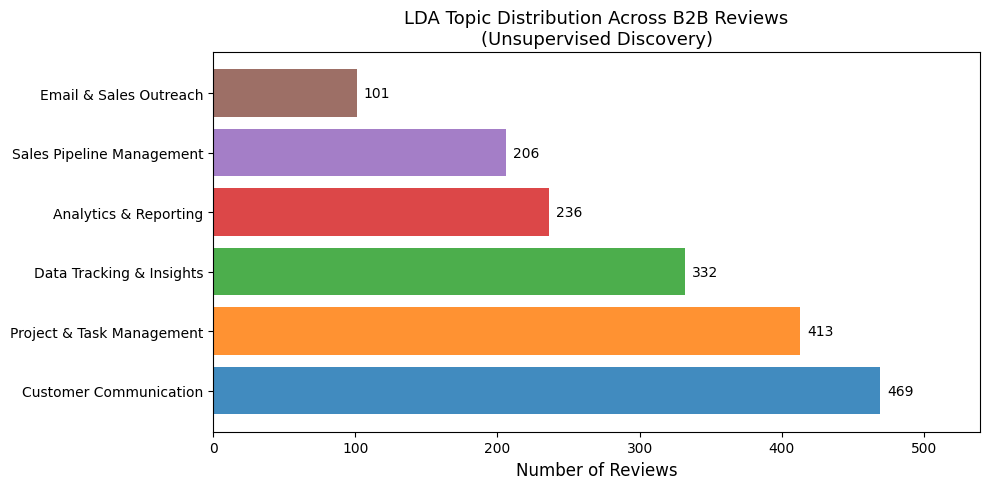

✅ Saved: lda_topic_distribution.png


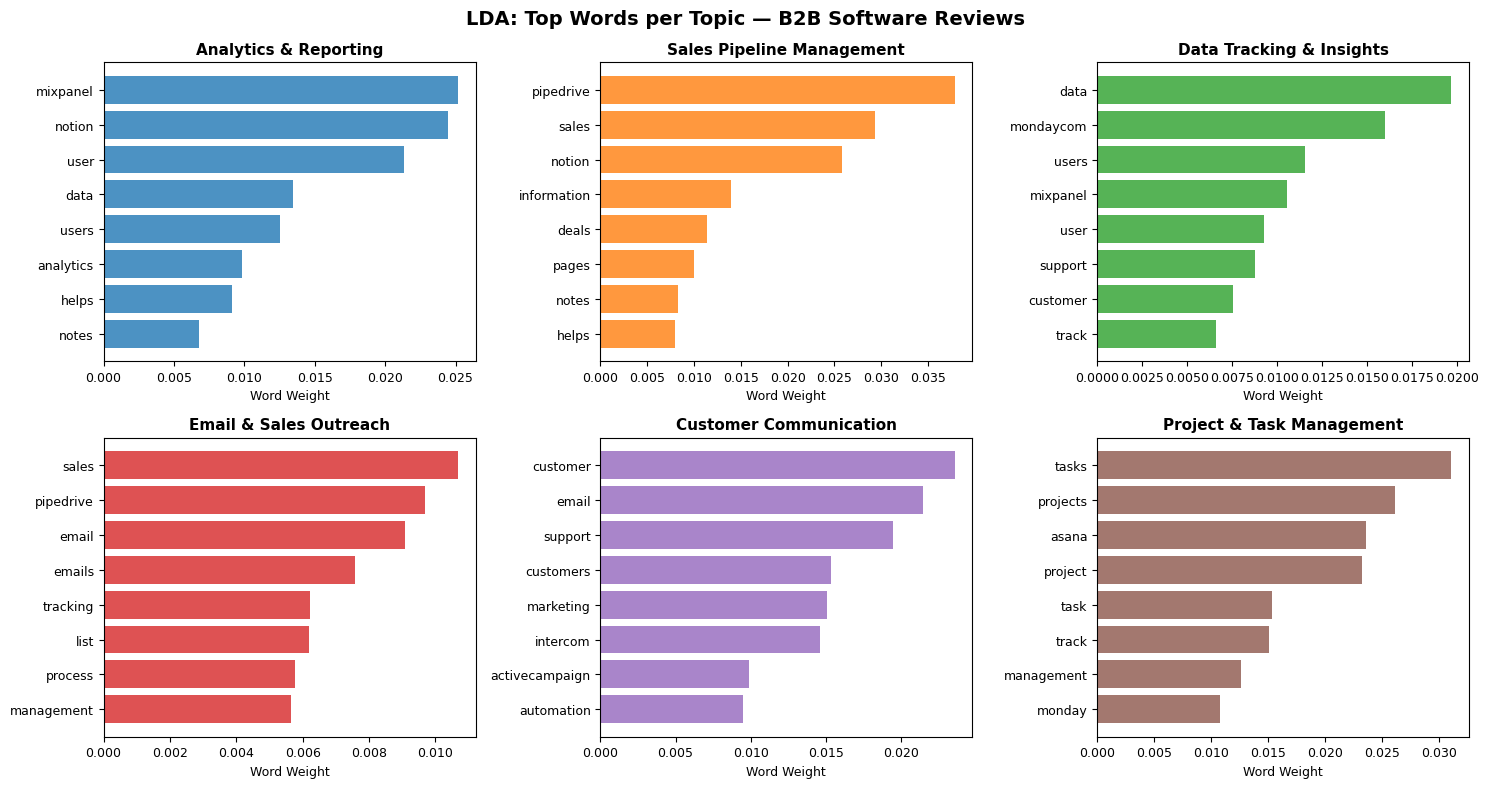

✅ Saved: lda_top_words.png

TOPIC vs INTENT LABEL OVERLAP
(Proves that topics ≠ intents)
topic_label           Analytics & Reporting  Customer Communication  \
intent_label                                                          
Advocacy Intent                          42                      74   
Churn Intent                              9                      35   
Evaluation Intent                        74                     107   
High Purchase Intent                      7                      45   
Neutral                                 104                     208   

topic_label           Data Tracking & Insights  Email & Sales Outreach  \
intent_label                                                             
Advocacy Intent                             57                      26   
Churn Intent                                16                       2   
Evaluation Intent                          103                      32   
High Purchase Intent                       

In [11]:
import matplotlib.colors as mcolors

colors = list(mcolors.TABLEAU_COLORS.values())[:NUM_TOPICS]

# Chart 1 — Topic distribution
topic_counts = df["topic_label"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(topic_counts.index, topic_counts.values, color=colors, alpha=0.85)
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
ax.set_xlabel("Number of Reviews", fontsize=12)
ax.set_title("LDA Topic Distribution Across B2B Reviews\n(Unsupervised Discovery)", fontsize=13)
ax.set_xlim(0, topic_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lda_topic_distribution.png', dpi=150)
plt.show()
print("✅ Saved: lda_topic_distribution.png")

# Chart 2 — Top words per topic
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx in range(NUM_TOPICS):
    top_words = lda_model.show_topic(idx, topn=8)
    words = [w for w, _ in top_words]
    weights = [p for _, p in top_words]
    label = TOPIC_LABELS.get(idx, f"Topic {idx}")
    axes[idx].barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.8)
    axes[idx].set_title(f"{label}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Word Weight", fontsize=9)
    axes[idx].tick_params(labelsize=9)
plt.suptitle("LDA: Top Words per Topic — B2B Software Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lda_top_words.png', dpi=150)
plt.show()
print("✅ Saved: lda_top_words.png")

# Chart 3 — Crosstab (KEY THESIS INSIGHT)
print("\nTOPIC vs INTENT LABEL OVERLAP")
print("(Proves that topics ≠ intents)")
print("=" * 60)
cross_tab = pd.crosstab(df["intent_label"], df["topic_label"])
print(cross_tab)

# Save results
df[["clean_review", "intent_label", "dominant_topic", "topic_label", "topic_probability"]].to_csv(
    '/content/drive/MyDrive/lda_results.csv', index=False
)
print("\n✅ Saved: lda_results.csv")

## **Zero-Shot Classification**

In [12]:
from transformers import pipeline as zs_pipeline
import numpy as np

CANDIDATE_LABELS = [
    "the reviewer purchased or selected this software",
    "the reviewer wants to cancel or switch to a competitor",
    "the reviewer is evaluating or comparing software options",
    "the reviewer strongly recommends this software to others",
    "the reviewer is describing their general experience",
]

LABEL_MAP = {
    "the reviewer purchased or selected this software": "High Purchase Intent",
    "the reviewer wants to cancel or switch to a competitor": "Churn Intent",
    "the reviewer is evaluating or comparing software options": "Evaluation Intent",
    "the reviewer strongly recommends this software to others": "Advocacy Intent",
    "the reviewer is describing their general experience": "Neutral",
}

LABELS = ["High Purchase Intent", "Churn Intent", "Evaluation Intent", "Advocacy Intent", "Neutral"]

# Sample 300 reviews
SAMPLE_SIZE = 300
df_zs = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"✅ Ready to classify {len(df_zs)} reviews")
print(df_zs["intent_label"].value_counts())

✅ Ready to classify 300 reviews
intent_label
Neutral                 126
Evaluation Intent        77
Advocacy Intent          65
Churn Intent             16
High Purchase Intent     16
Name: count, dtype: int64


In [13]:
print("Loading zero-shot model... (~2 min first time)")
zero_shot = zs_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)
print("✅ Model loaded!")

Loading zero-shot model... (~2 min first time)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model loaded!


In [14]:
print(f"Classifying {len(df_zs)} reviews... (~8-10 min, go grab a coffee! ☕)")

predictions = []
confidences = []

for i, text in enumerate(df_zs["clean_review"]):
    result = zero_shot(
        text[:512],
        candidate_labels=CANDIDATE_LABELS,
        multi_label=False
    )
    predictions.append(LABEL_MAP[result["labels"][0]])
    confidences.append(result["scores"][0])

    if (i + 1) % 50 == 0:
        print(f"  ✓ {i+1}/{len(df_zs)} done...")

df_zs["zero_shot_prediction"] = predictions
df_zs["zero_shot_confidence"] = confidences
print("✅ Classification complete!")

Classifying 300 reviews... (~8-10 min, go grab a coffee! ☕)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  ✓ 50/300 done...
  ✓ 100/300 done...
  ✓ 150/300 done...
  ✓ 200/300 done...
  ✓ 250/300 done...
  ✓ 300/300 done...
✅ Classification complete!


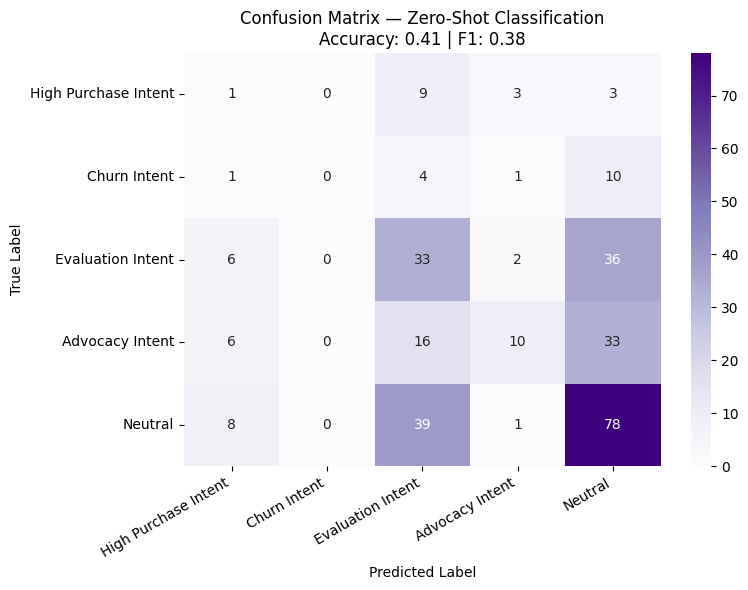

✅ Saved: zero_shot_confusion_matrix.png


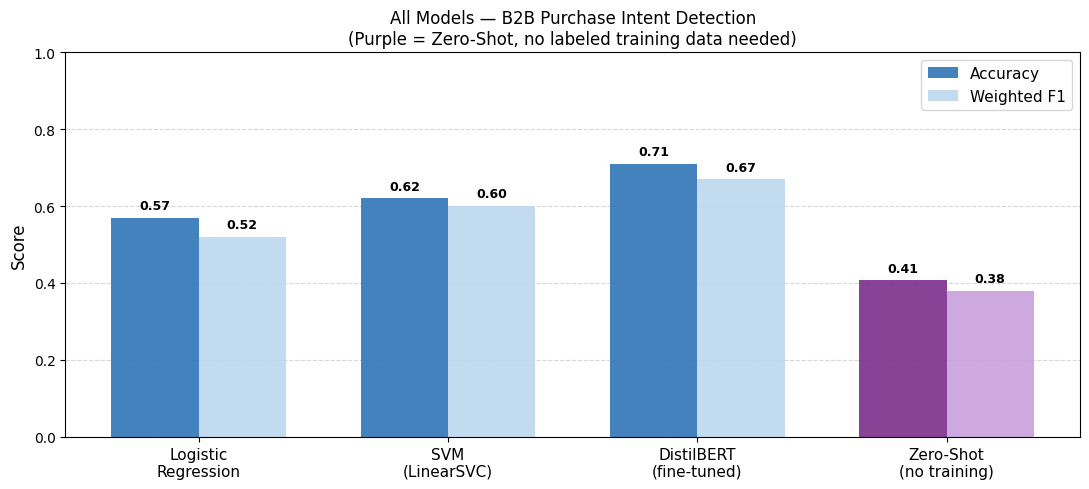

✅ Saved: full_model_comparison.png
✅ Saved: zero_shot_results.csv

🎉 Zero-Shot COMPLETE!


In [16]:
import seaborn as sns

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title(f"Confusion Matrix — Zero-Shot Classification\nAccuracy: {acc:.2f} | F1: {wf1:.2f}", fontsize=12)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/zero_shot_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: zero_shot_confusion_matrix.png")

# Full comparison chart
DISTILBERT_ACC = 0.71
DISTILBERT_F1  = 0.67

comparison = pd.DataFrame({
    "Model": ["Logistic\nRegression", "SVM\n(LinearSVC)", "DistilBERT\n(fine-tuned)", "Zero-Shot\n(no training)"],
    "Accuracy":    [0.57, 0.62, DISTILBERT_ACC, acc],
    "Weighted F1": [0.52, 0.60, DISTILBERT_F1,  wf1],
})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison))
width = 0.35
colors_acc = ["#2E75B6", "#2E75B6", "#2E75B6", "#7B2D8B"]
colors_f1  = ["#BDD7EE", "#BDD7EE", "#BDD7EE", "#C9A0DC"]

bars1 = ax.bar(x - width/2, comparison["Accuracy"], width, color=colors_acc, alpha=0.9, label="Accuracy")
bars2 = ax.bar(x + width/2, comparison["Weighted F1"], width, color=colors_f1, alpha=0.9, label="Weighted F1")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f"{h:.2f}",
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title("All Models — B2B Purchase Intent Detection\n(Purple = Zero-Shot, no labeled training data needed)", fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/full_model_comparison.png', dpi=150)
plt.show()
print("✅ Saved: full_model_comparison.png")

df_zs[["clean_review", "intent_label", "zero_shot_prediction", "zero_shot_confidence"]].to_csv(
    '/content/drive/MyDrive/zero_shot_results.csv', index=False
)
print("✅ Saved: zero_shot_results.csv")
print(f"\n🎉 Zero-Shot COMPLETE!")

## **SYNTHETIC DATASET EXPERIMENT**

In [17]:
import random

TEMPLATES = {
    "High Purchase Intent": [
        "After evaluating several options, we chose {product} for our {team} team.",
        "We switched to {product} after comparing multiple vendors. Best decision we made.",
        "Our company selected {product} following a thorough evaluation process.",
        "We implemented {product} last quarter after a competitive selection process.",
        "Decided to go with {product} after testing three alternatives. Very happy.",
        "We purchased {product} for our {size} organization after a 30-day trial.",
        "After reviewing {competitor} and {product}, we went with {product}.",
        "Our procurement team selected {product} following a detailed RFP process.",
        "We migrated from {competitor} to {product} and haven't looked back.",
        "After evaluating {competitor} and others, we chose {product}.",
    ],
    "Churn Intent": [
        "We are actively looking for alternatives to {product}. Too expensive.",
        "Not renewing our {product} subscription. The pricing has become unreasonable.",
        "We switched away from {product} after the latest price increase.",
        "Currently evaluating {competitor} as a replacement for {product}.",
        "We cancelled our {product} account. The support was terrible.",
        "Moving away from {product} — it no longer meets our needs.",
        "Considering switching to {competitor}. {product} is missing key features.",
        "Our team has decided not to renew with {product} next cycle.",
        "We're replacing {product} with a more cost-effective solution.",
        "After two years, we are leaving {product} due to poor customer service.",
    ],
    "Evaluation Intent": [
        "Currently evaluating {product} alongside {competitor}. Impressions so far are mixed.",
        "We are in the trial period with {product}. Testing core features.",
        "Comparing {product} vs {competitor} for our {team} use case.",
        "Running a 2-week pilot of {product} before making a final decision.",
        "Requested a demo of {product} — the sales team was very responsive.",
        "We are assessing {product} as part of our annual software review.",
        "In our evaluation phase — testing {product} against {competitor}.",
        "Before buying, we wanted to thoroughly test {product}'s automation features.",
        "Our team is piloting {product} and documenting our findings.",
        "We started a free trial of {product}. Will update after 30 days.",
    ],
    "Advocacy Intent": [
        "I highly recommend {product} to any {team} team looking for a great tool.",
        "{product} is an absolute game changer for our workflow. Five stars.",
        "Best {category} software I have ever used. Would recommend without hesitation.",
        "{product} has transformed the way our team works. Outstanding product.",
        "I cannot imagine running our {team} operations without {product}.",
        "{product} is a must-have for any serious {category} professional.",
        "Excellent tool. {product} delivers everything it promises and more.",
        "Love {product}. It has saved our team countless hours every week.",
        "{product} is best in class. I recommend it to everyone I meet.",
        "Our whole company uses {product} and we all love it. Highly recommend.",
    ],
    "Neutral": [
        "{product} has a solid set of features for {category} teams.",
        "We have been using {product} for about a year. It works well for our needs.",
        "{product} integrates with most of the tools we already use.",
        "The onboarding for {product} took some time but the support team helped.",
        "{product} updates its interface regularly. Some changes are improvements.",
        "Our team uses {product} daily. It covers most of our {category} needs.",
        "{product} has good documentation and a reasonable learning curve.",
        "We use {product} for our {team} workflows. Generally satisfied.",
        "{product} pricing is on the higher end but the features justify it mostly.",
        "The mobile app for {product} could use improvement but desktop version is fine.",
    ],
}

PRODUCTS    = ["Pipedrive", "HubSpot", "ActiveCampaign", "Intercom", "Mixpanel", "Zendesk"]
COMPETITORS = ["Salesforce", "Monday.com", "Notion", "Asana", "Freshdesk", "Zoho"]
TEAMS       = ["sales", "marketing", "customer success", "operations", "product"]
SIZES       = ["50-person", "100-person", "enterprise", "mid-market", "growing"]
CATEGORIES  = ["CRM", "marketing automation", "customer support", "analytics"]

def fill_template(template):
    product    = random.choice(PRODUCTS)
    competitor = random.choice([c for c in COMPETITORS if c != product])
    return (template
            .replace("{product}",    product)
            .replace("{competitor}", competitor)
            .replace("{team}",       random.choice(TEAMS))
            .replace("{size}",       random.choice(SIZES))
            .replace("{category}",   random.choice(CATEGORIES)))

REVIEWS_PER_CLASS = 200
random.seed(42)

synthetic_rows = []
for intent, templates in TEMPLATES.items():
    for _ in range(REVIEWS_PER_CLASS):
        template = random.choice(templates)
        text = fill_template(template)
        if random.random() > 0.5:
            text = text + " " + fill_template(random.choice(TEMPLATES[intent]))
        synthetic_rows.append({"clean_review": text, "intent_label": intent})

synthetic_df = pd.DataFrame(synthetic_rows).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Generated {len(synthetic_df)} synthetic reviews")
print(synthetic_df["intent_label"].value_counts())

synthetic_df.to_csv('/content/drive/MyDrive/synthetic_reviews.csv', index=False)
print("✅ Saved: synthetic_reviews.csv")

# Show a few examples
print("\nSample synthetic reviews:")
for intent in LABELS:
    sample = synthetic_df[synthetic_df["intent_label"] == intent].iloc[0]["clean_review"]
    print(f"\n[{intent}]\n  {sample}")

✅ Generated 1000 synthetic reviews
intent_label
Evaluation Intent       200
Advocacy Intent         200
Neutral                 200
High Purchase Intent    200
Churn Intent            200
Name: count, dtype: int64
✅ Saved: synthetic_reviews.csv

Sample synthetic reviews:

[High Purchase Intent]
  We purchased HubSpot for our growing organization after a 30-day trial. After reviewing Zoho and ActiveCampaign, we went with ActiveCampaign.

[Churn Intent]
  We switched away from ActiveCampaign after the latest price increase. Moving away from Intercom — it no longer meets our needs.

[Evaluation Intent]
  In our evaluation phase — testing Pipedrive against Notion. Requested a demo of ActiveCampaign — the sales team was very responsive.

[Advocacy Intent]
  I cannot imagine running our customer success operations without Zendesk. I highly recommend HubSpot to any customer success team looking for a great tool.

[Neutral]
  We use Pipedrive for our product workflows. Generally satisfied. Int

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_scheduler

LABELS = ["High Purchase Intent", "Churn Intent", "Evaluation Intent", "Advocacy Intent", "Neutral"]
le = LabelEncoder()
le.fit(LABELS)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class IntentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=256)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

def train_and_evaluate(train_df, test_df, model_name):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  Train: {len(train_df)} | Test: {len(test_df)}")
    print(f"{'='*55}")

    y_train = le.transform(train_df["intent_label"])
    y_test  = le.transform(test_df["intent_label"])

    train_loader = DataLoader(IntentDataset(train_df["clean_review"].values, y_train), batch_size=16, shuffle=True)
    test_loader  = DataLoader(IntentDataset(test_df["clean_review"].values, y_test), batch_size=16)

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=len(LABELS)
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_scheduler("linear", optimizer=optimizer,
                               num_warmup_steps=0,
                               num_training_steps=3*len(train_loader))

    for epoch in range(3):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            outputs.loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += outputs.loss.item()
        print(f"  Epoch {epoch+1}/3 — Loss: {total_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = torch.argmax(model(**batch).logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(batch["labels"].cpu().numpy())

    y_pred_names = le.inverse_transform(all_preds)
    y_true_names = le.inverse_transform(all_true)

    acc = accuracy_score(y_true_names, y_pred_names)
    wf1 = f1_score(y_true_names, y_pred_names, average="weighted", zero_division=0)
    print(f"\n  ✅ Accuracy: {acc:.4f} | Weighted F1: {wf1:.4f}")
    print(classification_report(y_true_names, y_pred_names, labels=LABELS, zero_division=0))
    return acc, wf1, y_true_names, y_pred_names

# Split real data
real_train, real_test = train_test_split(
    df, test_size=0.2, stratify=df["intent_label"], random_state=42
)

print("✅ Setup complete!")
print(f"Real train: {len(real_train)} | Real test: {len(real_test)} | Synthetic: {len(synthetic_df)}")

✅ Setup complete!
Real train: 1405 | Real test: 352 | Synthetic: 1000


## **EXPERIMENT A: Train on REAL data**

In [28]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

✅ Device: cuda


In [29]:
print("⏳ EXPERIMENT A starting...")
acc_real, f1_real, y_true_real, y_pred_real = train_and_evaluate(
    real_train, real_test, "EXPERIMENT A: Real Data → Real Test"
)

⏳ EXPERIMENT A starting...

  EXPERIMENT A: Real Data → Real Test
  Train: 1405 | Test: 352


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Loss: 1.3348
  Epoch 2/3 — Loss: 1.2376
  Epoch 3/3 — Loss: 1.1102

  ✅ Accuracy: 0.5369 | Weighted F1: 0.4911
                      precision    recall  f1-score   support

High Purchase Intent       0.00      0.00      0.00        21
        Churn Intent       0.00      0.00      0.00        16
   Evaluation Intent       0.44      0.33      0.38        85
     Advocacy Intent       0.50      0.46      0.48        70
             Neutral       0.58      0.81      0.67       160

            accuracy                           0.54       352
           macro avg       0.30      0.32      0.31       352
        weighted avg       0.47      0.54      0.49       352



## **Experiment B**

In [30]:
print("⏳ EXPERIMENT B starting...")
acc_synth, f1_synth, y_true_synth, y_pred_synth = train_and_evaluate(
    synthetic_df, real_test, "EXPERIMENT B: Synthetic Data → Real Test"
)

⏳ EXPERIMENT B starting...

  EXPERIMENT B: Synthetic Data → Real Test
  Train: 1000 | Test: 352


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Loss: 1.0109
  Epoch 2/3 — Loss: 0.1797
  Epoch 3/3 — Loss: 0.0903

  ✅ Accuracy: 0.4403 | Weighted F1: 0.3209
                      precision    recall  f1-score   support

High Purchase Intent       0.00      0.00      0.00        21
        Churn Intent       0.00      0.00      0.00        16
   Evaluation Intent       0.00      0.00      0.00        85
     Advocacy Intent       0.33      0.19      0.24        70
             Neutral       0.46      0.89      0.60       160

            accuracy                           0.44       352
           macro avg       0.16      0.21      0.17       352
        weighted avg       0.27      0.44      0.32       352



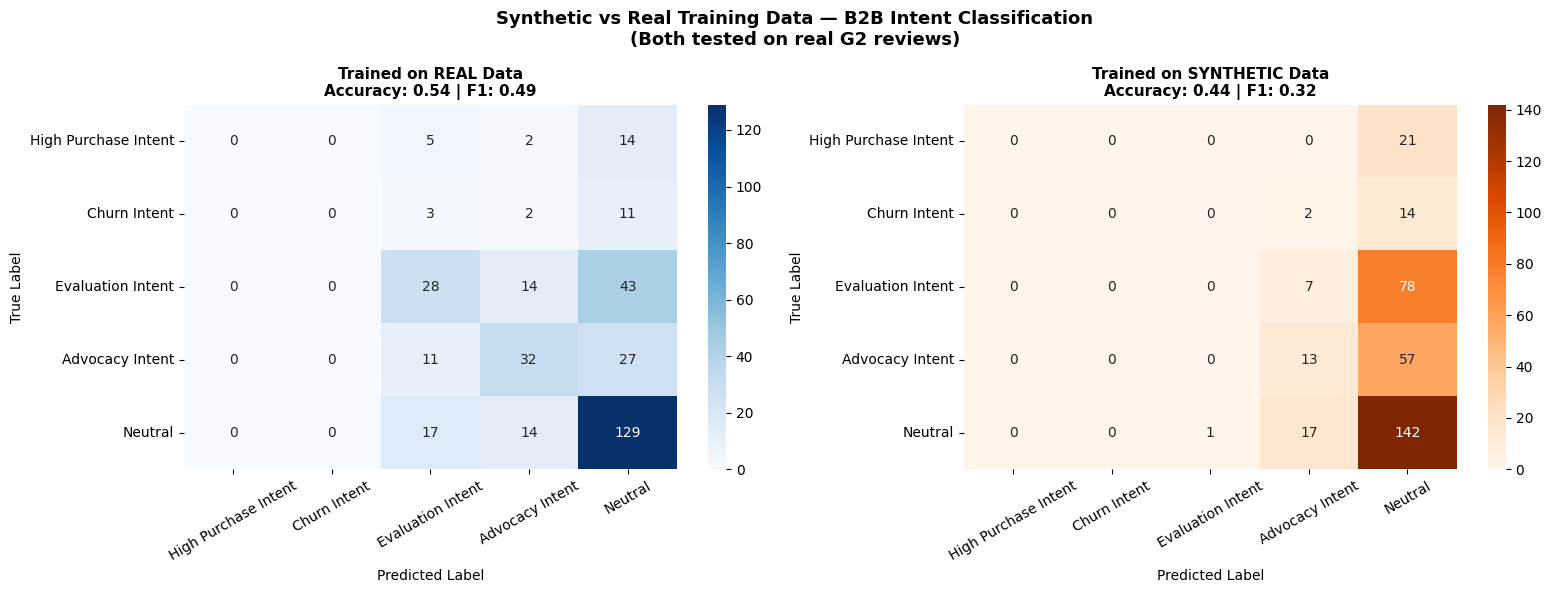

✅ Saved: synthetic_vs_real_comparison.png


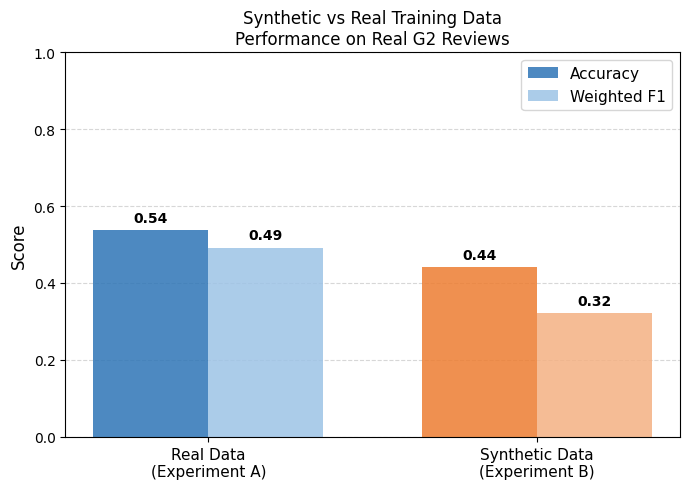

✅ Saved: synthetic_bar_chart.png
✅ Saved: synthetic_experiment_results.csv

🎉 ALL EXPERIMENTS COMPLETE!
Gap (Real - Synthetic): 0.0966


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_true, y_pred, title, cmap in [
    (axes[0], y_true_real, y_pred_real,
     f"Trained on REAL Data\nAccuracy: {acc_real:.2f} | F1: {f1_real:.2f}", "Blues"),
    (axes[1], y_true_synth, y_pred_synth,
     f"Trained on SYNTHETIC Data\nAccuracy: {acc_synth:.2f} | F1: {f1_synth:.2f}", "Oranges"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=LABELS, yticklabels=LABELS)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Synthetic vs Real Training Data — B2B Intent Classification\n(Both tested on real G2 reviews)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/synthetic_vs_real_comparison.png', dpi=150)
plt.show()
print("✅ Saved: synthetic_vs_real_comparison.png")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [acc_real, acc_synth], width,
               label="Accuracy", color=["#2E75B6", "#ED7D31"], alpha=0.85)
bars2 = ax.bar(x + width/2, [f1_real, f1_synth], width,
               label="Weighted F1", color=["#9DC3E6", "#F4B183"], alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f"{h:.2f}",
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Real Data\n(Experiment A)", "Synthetic Data\n(Experiment B)"], fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title("Synthetic vs Real Training Data\nPerformance on Real G2 Reviews", fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/synthetic_bar_chart.png', dpi=150)
plt.show()
print("✅ Saved: synthetic_bar_chart.png")

# Save results
pd.DataFrame({
    "Experiment": ["Real Data", "Synthetic Data"],
    "Accuracy": [round(acc_real, 4), round(acc_synth, 4)],
    "Weighted F1": [round(f1_real, 4), round(f1_synth, 4)],
    "Gap vs Real": [0.0, round(acc_synth - acc_real, 4)]
}).to_csv('/content/drive/MyDrive/synthetic_experiment_results.csv', index=False)

print("✅ Saved: synthetic_experiment_results.csv")
print(f"\n🎉 ALL EXPERIMENTS COMPLETE!")
print(f"Gap (Real - Synthetic): {acc_real - acc_synth:.4f}")

## **BERTopic Experiment**

In [3]:
!pip install bertopic --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
df_bert = pd.read_csv('/content/drive/MyDrive/b2b_reviews_balanced.csv')
df_bert["clean_review"] = df_bert["clean_review"].fillna("")
docs = df_bert["clean_review"].tolist()

print(df_bert["intent_label"].value_counts())

intent_label
Neutral                 800
Evaluation Intent       423
Advocacy Intent         351
High Purchase Intent    105
Churn Intent             79
Name: count, dtype: int64


In [5]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=3,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    vectorizer_model=vectorizer,
    nr_topics=8,
    min_topic_size=20,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
df_bert["bertopic_id"] = topics

print(f"Number of topics found: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Outlier reviews (topic -1): {topics.count(-1)}")

2026-03-05 11:53:13,813 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

2026-03-05 11:53:24,005 - BERTopic - Embedding - Completed ✓
2026-03-05 11:53:24,007 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-05 11:53:38,290 - BERTopic - Dimensionality - Completed ✓
2026-03-05 11:53:38,291 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-05 11:53:38,415 - BERTopic - Cluster - Completed ✓
2026-03-05 11:53:38,416 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-05 11:53:38,687 - BERTopic - Representation - Completed ✓
2026-03-05 11:53:38,688 - BERTopic - Topic reduction - Reducing number of topics
2026-03-05 11:53:38,698 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-05 11:53:38,957 - BERTopic - Representation - Completed ✓
2026-03-05 11:53:38,960 - BERTopic - Topic reduction - Reduced number of topics from 10 to 8


Number of topics found: 7
Outlier reviews (topic -1): 124


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info[topic_info["Topic"] != -1].to_string(index=False))

print("\nTop words per topic:")
for topic_id in sorted(set(topics)):
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)][:8]
    print(f"\nTopic {topic_id}: {', '.join(words)}")

 Topic  Count                                      Name                                                                                Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [7]:
BERTOPIC_LABELS = {
    0: "Project & Task Management",
    1: "Email Marketing & Automation",
    2: "Product Analytics & Reporting",
    3: "Sales CRM & Pipeline",
    4: "Knowledge Management & AI",
    5: "Customer Support & Chat",
    6: "Project Tracking & Collaboration",
    -1: "Outlier / Uncategorized"
}

df_bert["bertopic_label"] = df_bert["bertopic_id"].map(
    lambda x: BERTOPIC_LABELS.get(x, f"Topic {x}")
)

print("Labels assigned!")
print(df_bert["bertopic_label"].value_counts())

Labels assigned!
bertopic_label
Project & Task Management           325
Email Marketing & Automation        278
Product Analytics & Reporting       270
Sales CRM & Pipeline                214
Knowledge Management & AI           205
Customer Support & Chat             190
Project Tracking & Collaboration    152
Outlier / Uncategorized             124
Name: count, dtype: int64


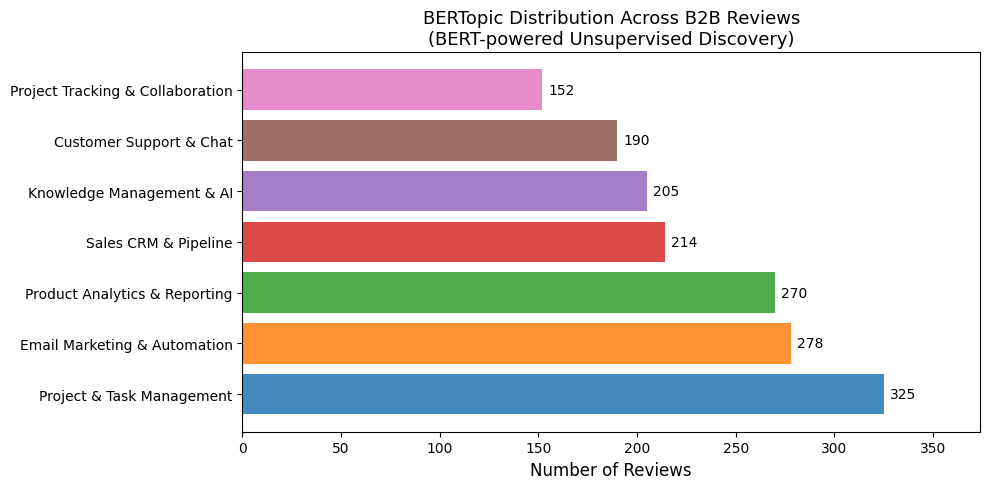

Saved: bertopic_distribution.png


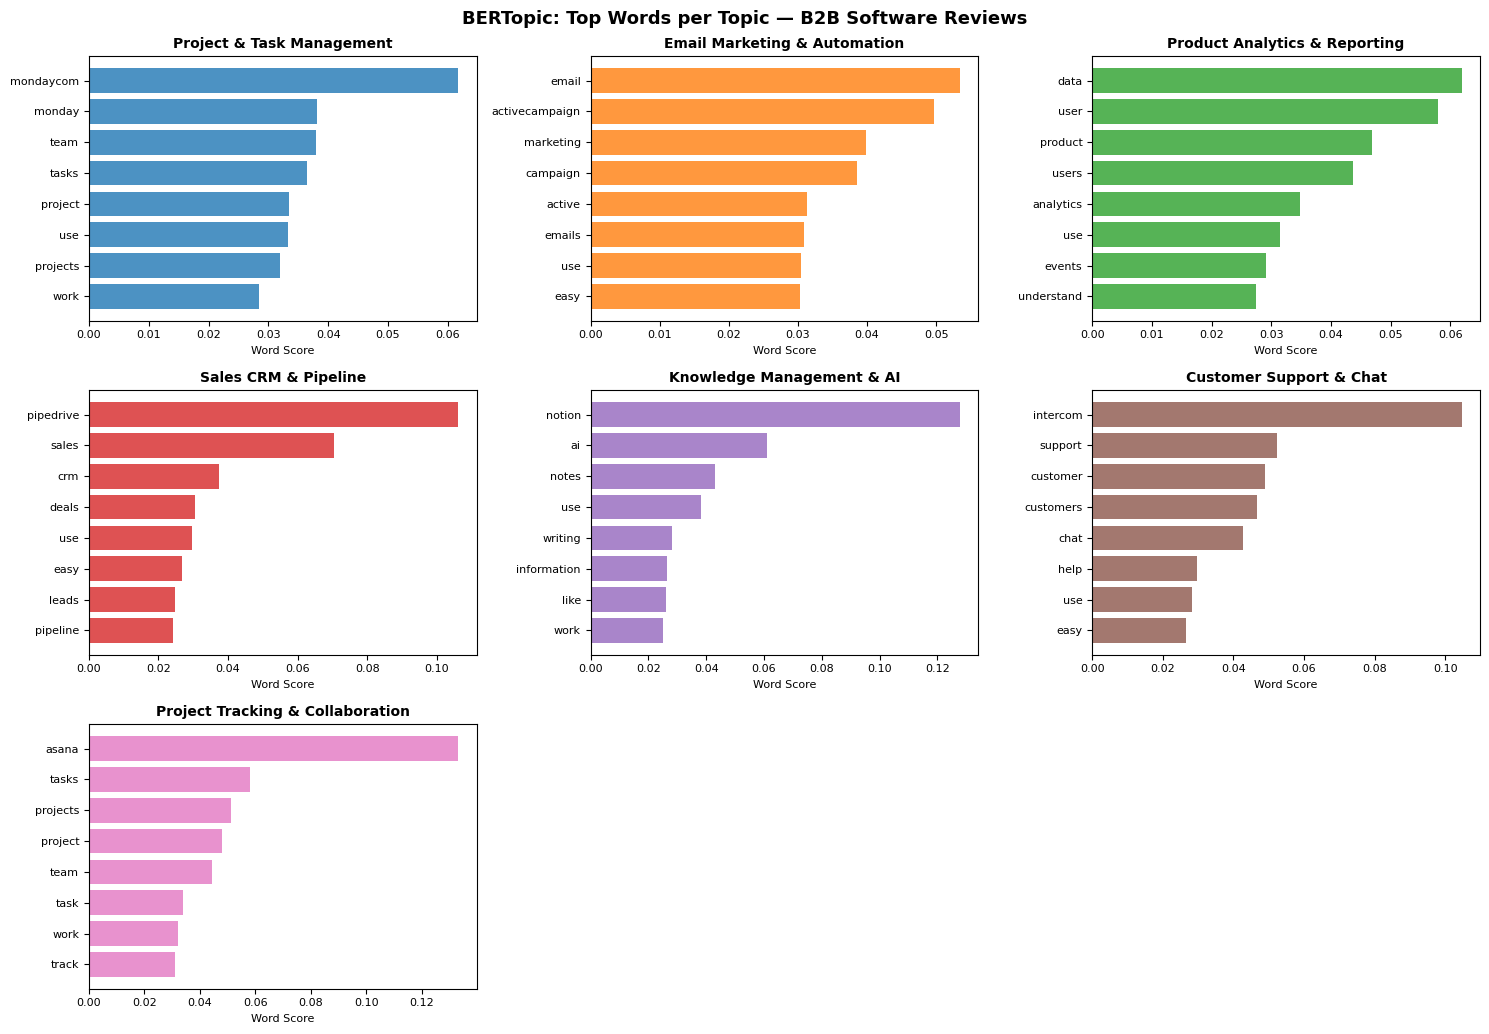

Saved: bertopic_top_words.png

BERTopic vs Intent Label Overlap:
bertopic_label        Customer Support & Chat  Email Marketing & Automation  \
intent_label                                                                  
Advocacy Intent                            29                            42   
Churn Intent                                6                            23   
Evaluation Intent                          35                            62   
High Purchase Intent                       17                            21   
Neutral                                   103                           130   

bertopic_label        Knowledge Management & AI  Outlier / Uncategorized  \
intent_label                                                               
Advocacy Intent                              46                       14   
Churn Intent                                 10                        7   
Evaluation Intent                            41                       32   
H

In [8]:
import matplotlib.colors as mcolors

valid_topics = [t for t in sorted(set(topics)) if t != -1]
n_topics = len(valid_topics)
colors = list(mcolors.TABLEAU_COLORS.values())[:n_topics]

# Chart 1: Topic distribution
topic_counts = df_bert[df_bert["bertopic_id"] != -1]["bertopic_label"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(topic_counts.index, topic_counts.values, color=colors, alpha=0.85)
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
ax.set_xlabel("Number of Reviews", fontsize=12)
ax.set_title("BERTopic Distribution Across B2B Reviews\n(BERT-powered Unsupervised Discovery)", fontsize=13)
ax.set_xlim(0, topic_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bertopic_distribution.png', dpi=150)
plt.show()
print("Saved: bertopic_distribution.png")

# Chart 2: Top words per topic
cols = 3
rows = (n_topics + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
axes = axes.flatten()

for i, topic_id in enumerate(valid_topics):
    top_words = topic_model.get_topic(topic_id)[:8]
    words   = [w for w, _ in top_words]
    weights = [s for _, s in top_words]
    label   = BERTOPIC_LABELS.get(topic_id, f"Topic {topic_id}")
    axes[i].barh(words[::-1], weights[::-1], color=colors[i % len(colors)], alpha=0.8)
    axes[i].set_title(label, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Word Score", fontsize=8)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BERTopic: Top Words per Topic — B2B Software Reviews", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bertopic_top_words.png', dpi=150)
plt.show()
print("Saved: bertopic_top_words.png")

print("\nBERTopic vs Intent Label Overlap:")
print(pd.crosstab(df_bert["intent_label"], df_bert["bertopic_label"]))

df_bert[["clean_review", "intent_label", "bertopic_id", "bertopic_label"]].to_csv(
    '/content/drive/MyDrive/bertopic_results.csv', index=False
)
print("Saved: bertopic_results.csv")
print("BERTopic COMPLETE!")

## **Few-Shot Classification Experiment**

In [1]:
!pip install transformers==4.40.0 sentence-transformers --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.7 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Imports ready!")

Imports ready!


In [2]:
df_fs = pd.read_csv('/content/drive/MyDrive/b2b_reviews_balanced.csv')
df_fs["clean_review"] = df_fs["clean_review"].fillna("")

LABELS = ["High Purchase Intent", "Churn Intent", "Evaluation Intent", "Advocacy Intent", "Neutral"]
le = LabelEncoder()
le.fit(LABELS)

train_pool, test_df = train_test_split(
    df_fs, test_size=0.2, stratify=df_fs["intent_label"], random_state=42
)

print(f"Loaded {len(df_fs)} reviews")
print(f"Train pool: {len(train_pool)} | Test: {len(test_df)}")

Loaded 1758 reviews
Train pool: 1406 | Test: 352


In [3]:
print("Loading sentence embedding model...")
embedder = SentenceTransformer("paraphrase-mpnet-base-v2")

print("Encoding all reviews (takes 2-3 min)...")
all_texts = df_fs["clean_review"].tolist()
all_embeddings = embedder.encode(all_texts, show_progress_bar=True)

print("Done! Embeddings shape:", all_embeddings.shape)

Loading sentence embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding all reviews (takes 2-3 min)...


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Done! Embeddings shape: (1758, 768)


In [4]:
def create_few_shot_dataset(k):
    samples = []
    for label in LABELS:
        class_df = train_pool[train_pool["intent_label"] == label]
        n = min(k, len(class_df))
        sampled = class_df.sample(n=n, random_state=42)
        samples.append(sampled)
    return pd.concat(samples).sample(frac=1, random_state=42).reset_index(drop=True)

def run_few_shot(k):
    print(f"\n{'='*50}")
    print(f"FEW-SHOT k={k} ({k*5} total training reviews)")
    print(f"{'='*50}")

    few_shot_df = create_few_shot_dataset(k)

    # Get embeddings for train and test using index positions
    train_idx = few_shot_df.index.tolist()
    test_idx  = test_df.index.tolist()

    X_train = all_embeddings[train_idx]
    y_train = le.transform(few_shot_df["intent_label"])
    X_test  = all_embeddings[test_idx]
    y_test  = le.transform(test_df["intent_label"])

    # Logistic Regression on top of embeddings
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    y_true_names = le.inverse_transform(y_test)
    y_pred_names = le.inverse_transform(preds)

    acc = accuracy_score(y_true_names, y_pred_names)
    wf1 = f1_score(y_true_names, y_pred_names, average="weighted", zero_division=0)

    print(f"k={k} | Accuracy: {acc:.4f} | Weighted F1: {wf1:.4f}")
    print(classification_report(y_true_names, y_pred_names, labels=LABELS, zero_division=0))

    return acc, wf1, y_true_names, y_pred_names

In [5]:
acc_3,  f1_3,  y_true_3,  y_pred_3  = run_few_shot(k=3)
acc_5,  f1_5,  y_true_5,  y_pred_5  = run_few_shot(k=5)
acc_10, f1_10, y_true_10, y_pred_10 = run_few_shot(k=10)

print("\nAll three done!")
print(f"k=3  -> Accuracy: {acc_3:.4f}")
print(f"k=5  -> Accuracy: {acc_5:.4f}")
print(f"k=10 -> Accuracy: {acc_10:.4f}")


FEW-SHOT k=3 (15 total training reviews)
k=3 | Accuracy: 0.1989 | Weighted F1: 0.2200
                      precision    recall  f1-score   support

High Purchase Intent       0.20      0.10      0.13        21
        Churn Intent       0.05      0.31      0.08        16
   Evaluation Intent       0.18      0.12      0.14        85
     Advocacy Intent       0.14      0.14      0.14        70
             Neutral       0.41      0.27      0.32       160

            accuracy                           0.20       352
           macro avg       0.19      0.19      0.16       352
        weighted avg       0.27      0.20      0.22       352


FEW-SHOT k=5 (25 total training reviews)
k=5 | Accuracy: 0.2330 | Weighted F1: 0.2567
                      precision    recall  f1-score   support

High Purchase Intent       0.11      0.33      0.17        21
        Churn Intent       0.02      0.06      0.03        16
   Evaluation Intent       0.20      0.19      0.19        85
     Advocacy In

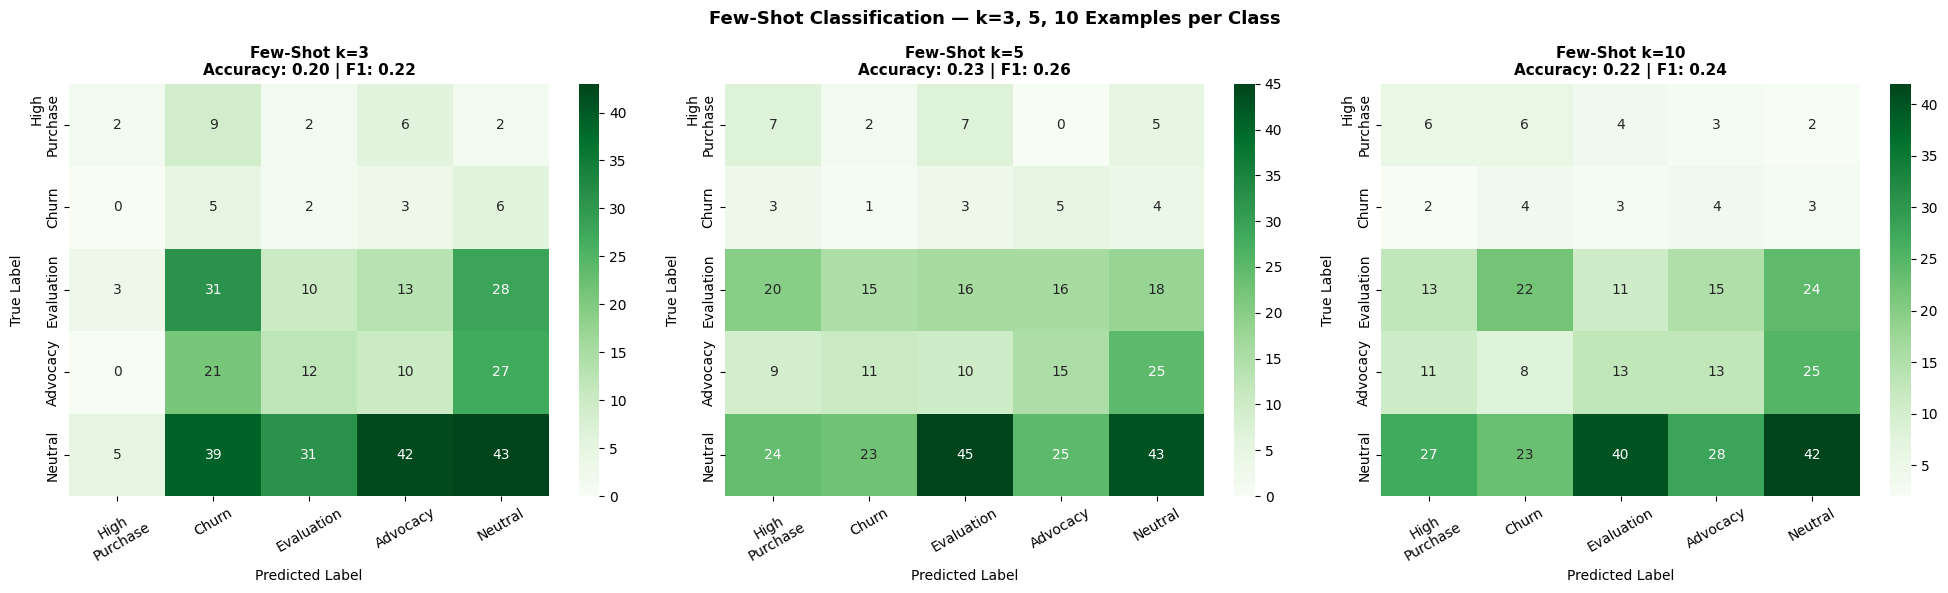

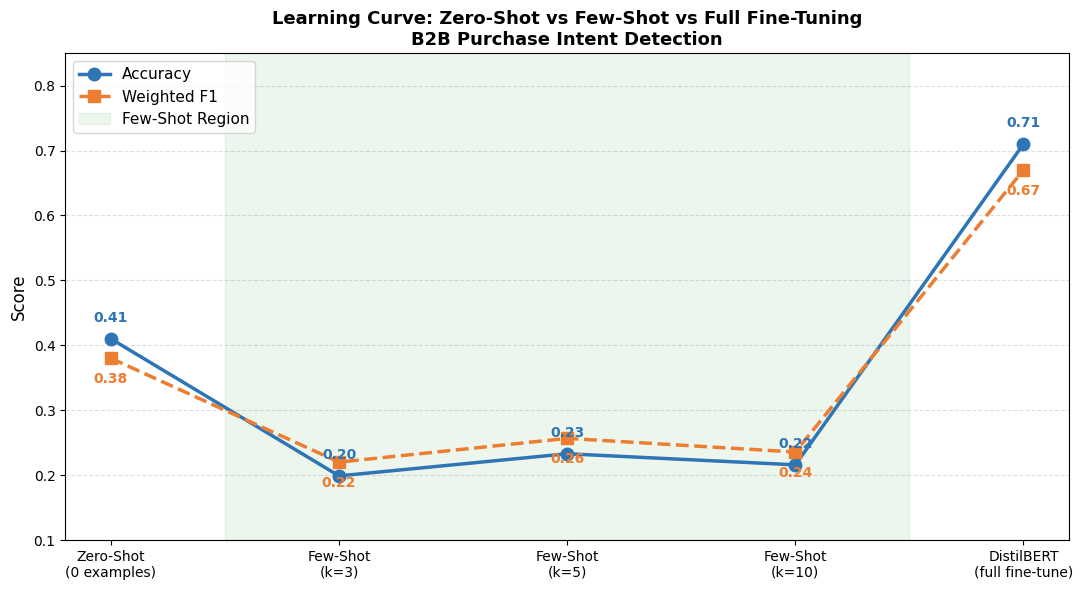

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
short_labels = ["High\nPurchase", "Churn", "Evaluation", "Advocacy", "Neutral"]

for ax, y_true, y_pred, k, acc, f1 in [
    (axes[0], y_true_3,  y_pred_3,  3,  acc_3,  f1_3),
    (axes[1], y_true_5,  y_pred_5,  5,  acc_5,  f1_5),
    (axes[2], y_true_10, y_pred_10, 10, acc_10, f1_10),
]:
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_title(f"Few-Shot k={k}\nAccuracy: {acc:.2f} | F1: {f1:.2f}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Few-Shot Classification — k=3, 5, 10 Examples per Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/few_shot_confusion_matrices.png', dpi=150)
plt.show()

# Learning curve: the money chart
DISTILBERT_ACC = 0.71
DISTILBERT_F1  = 0.67
ZEROSHOT_ACC   = 0.41
ZEROSHOT_F1    = 0.38

x_points    = [0, 1, 2, 3, 4]
acc_points  = [ZEROSHOT_ACC, acc_3, acc_5, acc_10, DISTILBERT_ACC]
f1_points   = [ZEROSHOT_F1,  f1_3,  f1_5,  f1_10,  DISTILBERT_F1]
x_labels    = [
    "Zero-Shot\n(0 examples)",
    "Few-Shot\n(k=3)",
    "Few-Shot\n(k=5)",
    "Few-Shot\n(k=10)",
    "DistilBERT\n(full fine-tune)"
]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x_points, acc_points, "o-", color="#2E75B6", linewidth=2.5,
        markersize=9, label="Accuracy", zorder=3)
ax.plot(x_points, f1_points,  "s--", color="#ED7D31", linewidth=2.5,
        markersize=9, label="Weighted F1", zorder=3)

for i, (acc, f1) in enumerate(zip(acc_points, f1_points)):
    ax.annotate(f"{acc:.2f}", (x_points[i], acc), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10,
                fontweight="bold", color="#2E75B6")
    ax.annotate(f"{f1:.2f}", (x_points[i], f1), textcoords="offset points",
                xytext=(0, -18), ha="center", fontsize=10,
                fontweight="bold", color="#ED7D31")

ax.axvspan(0.5, 3.5, alpha=0.07, color="green", label="Few-Shot Region")
ax.set_xticks(x_points)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.1, 0.85)
ax.set_title("Learning Curve: Zero-Shot vs Few-Shot vs Full Fine-Tuning\nB2B Purchase Intent Detection",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/learning_curve.png', dpi=150)
plt.show()

pd.DataFrame({
    "Model": ["Zero-Shot", "Few-Shot k=3", "Few-Shot k=5", "Few-Shot k=10", "DistilBERT"],
    "Examples per class": [0, 3, 5, 10, "~280"],
    "Accuracy": [ZEROSHOT_ACC, acc_3, acc_5, acc_10, DISTILBERT_ACC],
    "Weighted F1": [ZEROSHOT_F1, f1_3, f1_5, f1_10, DISTILBERT_F1]
}).to_csv('/content/drive/MyDrive/few_shot_results.csv', index=False)